In [1]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision import transforms
import random
import sys
sys.path.append('/home/apassi1/deepbottleneck')
from calc_encoding import *
import umap
import matplotlib.pyplot as plt

/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/apassi1/.conda/envs/backprop_pca/lib/python3

In [2]:
# ----- Step 1: All your code for defining the dataset/data_loader as before -----

# Seed for reproducibility
seed = 42
random.seed(seed)
torch.manual_seed(seed)

# Config
folder_path = "/data/shared/datasets/imagenet"
images_per_class = 1000
batch_size = 30
map_file_path = "/data/shared/datasets/imagenet/map_clsloc.txt"

# List of target categories (as human-readable labels from map_clsloc.txt)
target_labels = ["brittany_spaniel", "celery", "dalmatian", "gila_monster", "lion", "pumpkin", 
"canoe", "cockroach", "fire_engine", "skunk"]

# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load full ImageNet dataset
dataset = ImageFolder(root=folder_path, transform=transform)
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
class_to_idx = dataset.class_to_idx  # class name (WNID) → index

# Step 1: Load WNID ↔ human-readable label mapping
label_to_wnid = {}
with open(map_file_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            wnid = parts[0]
            label = "_".join(parts[1:])  # Normalize to match underscore-separated input
            label_to_wnid[label] = wnid

# Step 2: Match your target labels to WNIDs
matched_wnids = []
for label in target_labels:
    if label not in label_to_wnid:
        raise ValueError(f"Label '{label}' not found in {map_file_path}")
    matched_wnids.append(label_to_wnid[label])

# Step 3: Get class indices in ImageFolder that match selected WNIDs
matched_class_indices = []
for wnid in matched_wnids:
    if wnid not in class_to_idx:
        raise ValueError(f"WNID '{wnid}' not found in dataset classes")
    matched_class_indices.append(class_to_idx[wnid])

# Step 4: Collect image indices per class
class_to_indices = {class_idx: [] for class_idx in matched_class_indices}
for idx, (_, label_idx) in enumerate(dataset.imgs):
    if label_idx in class_to_indices:
        class_to_indices[label_idx].append(idx)

# Step 5: Sample 100 images per selected class
subset_indices = []
for class_idx in matched_class_indices:
    available = class_to_indices[class_idx]
    if len(available) < images_per_class:
        raise ValueError(f"Class '{idx_to_class[class_idx]}' has only {len(available)} images")
    subset_indices.extend(random.sample(available, images_per_class))

# Step 6: Create Subset and DataLoader
subset = Subset(dataset, subset_indices)
data_loader = DataLoader(subset, batch_size=batch_size, shuffle=False)

# Optional: Class mapping for reference
wnid_to_label = {v: k for k, v in label_to_wnid.items()}
selected_class_labels = [wnid_to_label[idx_to_class[i]] for i in matched_class_indices]
print("Selected classes:", selected_class_labels)

subset = Subset(dataset, subset_indices)
data_loader = DataLoader(subset, batch_size=batch_size, shuffle=False)

Selected classes: ['brittany_spaniel', 'celery', 'dalmatian', 'gila_monster', 'lion', 'pumpkin', 'canoe', 'cockroach', 'fire_engine', 'skunk']


In [3]:
# ----- Step 2: Border detection and filtering -----
def borderless_indices_in_loader(data_loader, border_width=5, threshold=0.25):
    """
    Returns the *original* indices (in your wrapped dataset) of the images that have NO borders.
    Works with a data_loader yielding batches [(images, labels)...].
    """
    from tqdm import tqdm

    borderless_indices = []
    subset = data_loader.dataset
    # Handle Subset wrapping, for your setting this is always a Subset
    true_indices = subset.indices if isinstance(subset, Subset) else list(range(len(subset)))

    running_idx = 0
    for batch in tqdm(data_loader, desc="Scanning for borderless images"):
        images, _ = batch
        batch_size = images.shape[0]
        images_np = images.permute(0, 2, 3, 1).numpy()
        for i in range(batch_size):
            img_np = images_np[i]
            h, w, _ = img_np.shape
            if img_np.max() <= 1.0:
                img_np = (img_np * 255).astype(np.uint8)
            # Border extraction
            top = img_np[:border_width, :, :]
            bottom = img_np[-border_width:, :, :]
            left = img_np[:, :border_width, :]
            right = img_np[:, -border_width:, :]
            is_uniform = all([
                np.all(top == top[0,0,:]),
                np.all(bottom == bottom[0,0,:]),
                np.all(left == left[0,0,:]),
                np.all(right == right[0,0,:])
            ])
            if is_uniform:
                border_color = img_np[0, 0, :]
                matches = np.all(img_np == border_color, axis=-1)
                fraction = np.sum(matches) / (h * w)
                has_border = fraction <= threshold
                has_border = True # STRICT CONDITION
            else:
                has_border = False
            if not has_border:
                borderless_indices.append(true_indices[running_idx + i])
        running_idx += batch_size
    return borderless_indices

# Find indices of borderless images in the *original* dataset
borderless_indices = borderless_indices_in_loader(data_loader, border_width=1, threshold=1)
print(f"Total borderless images: {len(borderless_indices)} / {len(subset)}")

# ----- Step 3: Make a new DataLoader including only borderless images -----
borderless_subset = Subset(dataset, borderless_indices)
borderless_loader = DataLoader(borderless_subset, batch_size=batch_size, shuffle=False)

Scanning for borderless images: 100%|██████████| 334/334 [00:22<00:00, 14.86it/s]

Total borderless images: 9904 / 10000


In [4]:
# step 2: get model
layerid = 5
model_label = "lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore1"
# model_label = "lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore1"

# model = get_model(model_label, model_type='trained_bottleneck', ckpt_epoch=58650)
model = get_model(model_label, model_type='trained_bottleneck', ckpt_epoch=0)
model = model.cuda()
model = model[:(layerid+1)]

Making PCA Model, var_path=/data/apassi1/variance-coefs/pca_org_arch_10k_images_sys_protocol/, std_path=/data/apassi1/std_coefs/pca_org_arch_10k_images_sys_protocol/, static_norm=True
Initialized PCA Model, static_norm=True


In [5]:
# --------- Step 4: Use borderless_loader in your usual workflow ----------

# Example: Repeat your activation extraction/UMAP **with borderless_loader** instead of data_loader
all_labels = []
m = []
for batch_input, labels in borderless_loader:
    batch_input = batch_input.cuda()
    with torch.no_grad():
        output = model(batch_input)
    output = output.full_view()
    output = output.reshape(output.shape[0], -1).cpu()
    m.append(output)
    all_labels.extend(labels.cpu().tolist())

# ... The rest of your dimensionality reduction and UMAP code ...

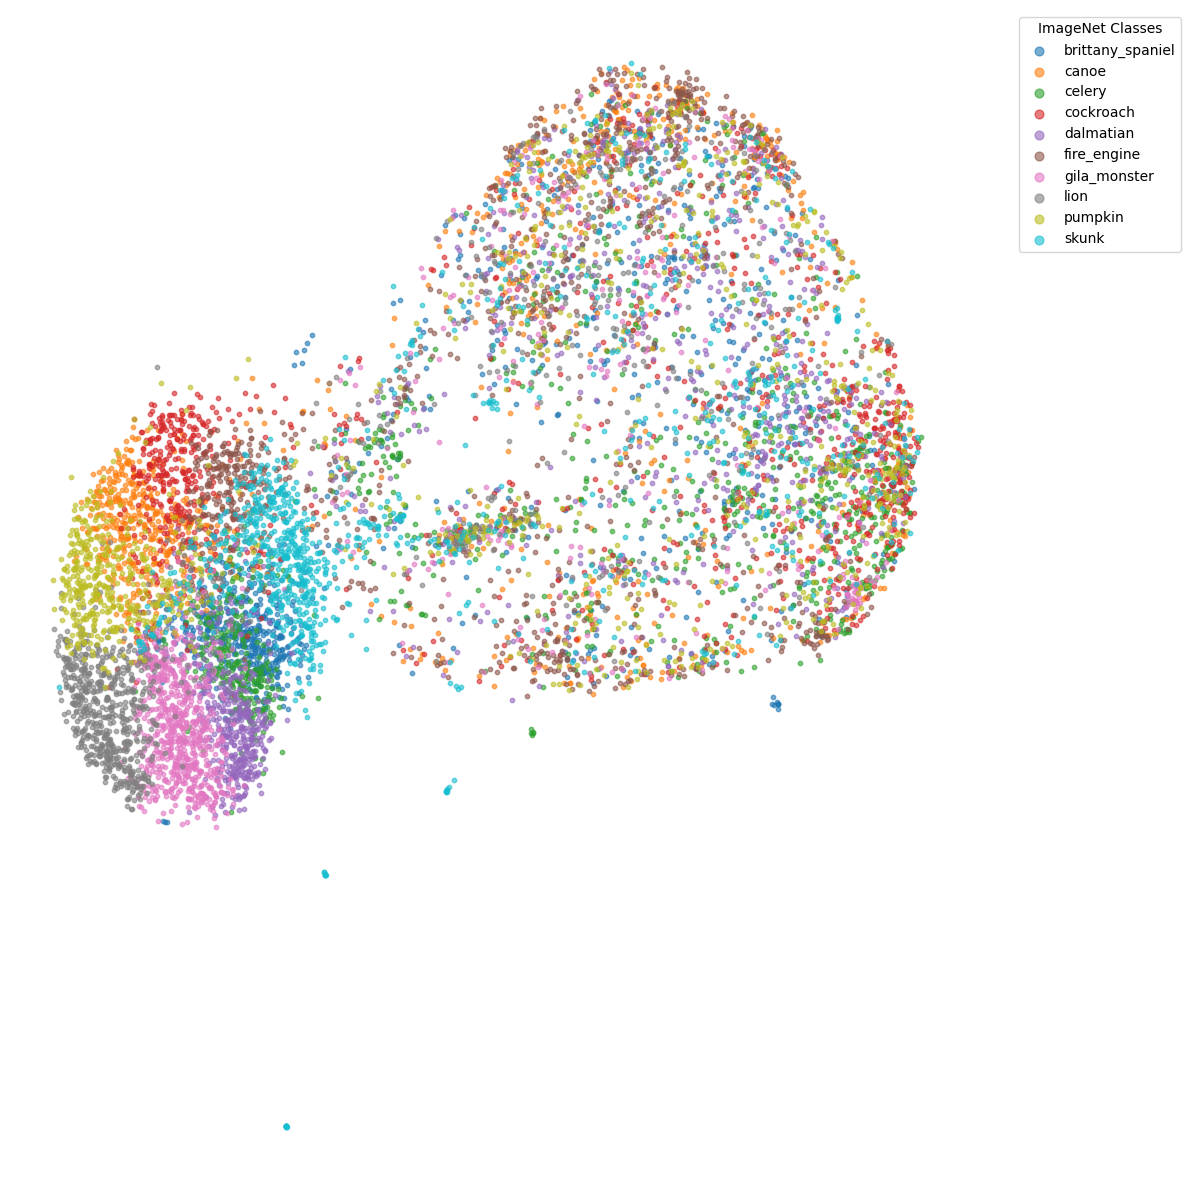

In [6]:
m = torch.cat(m, dim=0)

# Dimensionality reduction using Sparse Random Projection
n_samples = m.shape[0]
n_features = m.shape[1]
n_components = compute_johnson_lindenstrauss_limit(n_samples=n_samples, epsilon=0.1)

sparse_random_projection = SparseRandomProjection(
    n_components=n_components,
    density=None,
    seed=0,
    allow_expansion=False
)
    
m = sparse_random_projection(m).cpu()

# UMAP embedding
mapper = umap.UMAP(random_state=seed)
x_umap = mapper.fit_transform(m)

# Convert label indices to WordNet IDs
wnid_labels = [idx_to_class[idx] for idx in all_labels]

# Convert WordNet IDs to human-readable names
label_names = [wnid_to_label.get(wnid, wnid) for wnid in wnid_labels]

# Assign each class a color
unique_labels = sorted(set(label_names))
label_to_color = {label: plt.cm.tab10(i % 10) for i, label in enumerate(unique_labels)}
colors = [label_to_color[label] for label in label_names]

# Plotting
plt.figure(figsize=(12, 12))
for label in unique_labels:
    idxs = [i for i, lbl in enumerate(label_names) if lbl == label]
    plt.scatter(x_umap[idxs, 0], x_umap[idxs, 1], s=10, color=label_to_color[label], label=label, alpha=0.6)

plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left', title="ImageNet Classes")
plt.axis("off")
plt.tight_layout()
plt.show()